In [1]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
X, y = load_iris(return_X_y=True, as_frame=True)

In [3]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
len(y)

150

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

In [7]:
importance

sepal length (cm)    0.106128
sepal width (cm)     0.021678
petal length (cm)    0.436130
petal width (cm)     0.436065
dtype: float64

In [8]:
importance = importance.sort_values(ascending=True)  # 从小到大，方便横向柱状图展示

In [9]:
importance

sepal width (cm)     0.021678
sepal length (cm)    0.106128
petal width (cm)     0.436065
petal length (cm)    0.436130
dtype: float64

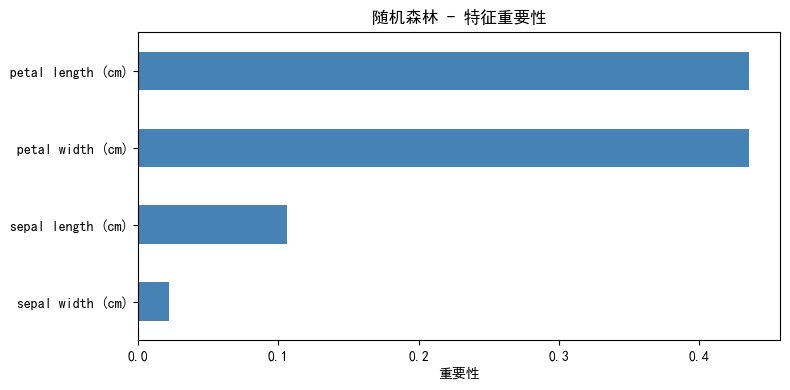

In [13]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot.barh(ax=ax, color='steelblue')

ax.set_xlabel('重要性')
ax.set_title('随机森林 - 特征重要性')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)

plt.show()

In [14]:
print("特征重要性排序:")
for name, score in importance[::-1].items():
    print(f"  {name}: {score:.4f}")

特征重要性排序:
  petal length (cm): 0.4361
  petal width (cm): 0.4361
  sepal length (cm): 0.1061
  sepal width (cm): 0.0217
